- 환경 확인

In [1]:
import tensorflow as tf
import torch

print("TensorFlow:", tf.__version__)
print("PyTorch:", torch.__version__)
print("TensorFlow GPU:", tf.config.list_physical_devices("GPU"))
print("PyTorch CUDA:", torch.cuda.is_available())

TensorFlow: 2.19.0
PyTorch: 2.12.0
TensorFlow GPU: []
PyTorch CUDA: False


- 데이터셋 준비하기

In [2]:
import tensorflow as tf

fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()

(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist

X_train, y_train = X_train_full[:50000], y_train_full[:50000]
X_valid, y_valid = X_train_full[50000:], y_train_full[50000:]

# 데이터 전처리
X_train = X_train.astype("float32") / 255.0
X_valid = X_valid.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0
X_train = X_train.reshape(-1, 28 * 28)
X_valid = X_valid.reshape(-1, 28 * 28)
X_test = X_test.reshape(-1, 28 * 28)

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

print("훈련 세트 크기:", X_train.shape)
print("검증 세트 크기:", X_valid.shape)
print("테스트 세트 크기:", X_test.shape)
print("클래스 이름:", class_names)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 8us/step 
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
훈련 세트 크기: (50000, 784)
검증 세트 크기: (10000, 784)
테스트 세트 크기: (10000, 784)
클래스 이름: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


- Sequential API로 모델 생성

    Sequential 모델은 가장 간단한 Keras의 신경망 모델이다. 순서대로 연결된 층을 일렬로 쌓아서 구성한다. 이를 Sequential API라고 부른다.

In [3]:
tf.random.set_seed(42)

model = tf.keras.Sequential()

model.add(tf.keras.layers.Input(shape=(28 * 28,)))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(300, activation="relu"))
model.add(tf.keras.layers.Dense(100, activation="relu"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

- 모델 컴파일

In [4]:
model.compile(
    loss="sparse_categorical_crossentropy", 
    optimizer="sgd", 
    metrics=["accuracy"]
)

- 모델 훈련과 평가

In [5]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    validation_data=(X_valid, y_valid)   
)

Epoch 1/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7675 - loss: 0.7203 - val_accuracy: 0.8209 - val_loss: 0.5292
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8291 - loss: 0.4919 - val_accuracy: 0.8417 - val_loss: 0.4654
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8426 - loss: 0.4463 - val_accuracy: 0.8508 - val_loss: 0.4337
Epoch 4/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8527 - loss: 0.4186 - val_accuracy: 0.8570 - val_loss: 0.4123
Epoch 5/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8596 - loss: 0.3981 - val_accuracy: 0.8628 - val_loss: 0.3974
Epoch 6/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8654 - loss: 0.3818 - val_accuracy: 0.8656 - val_loss: 0.3857
Epoch 7/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8697 - loss: 0.3684 - val_accuracy: 0.8688 - val_loss: 0.3763
Epoch 8/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8738 - loss: 0.3565 - 

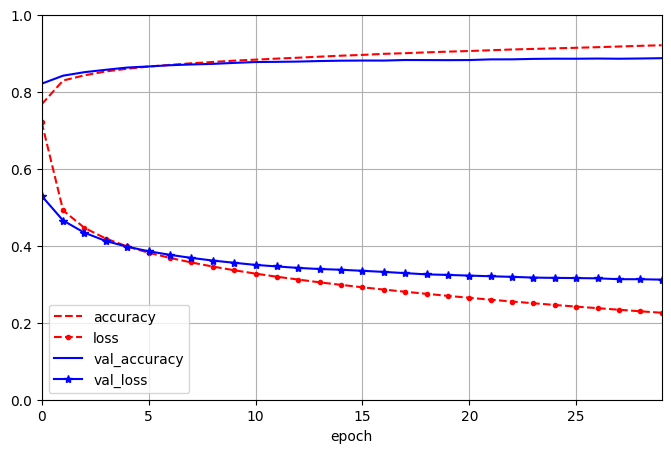

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

pd.DataFrame(history.history).plot(
    figsize=(8, 5),
    xlim=(0, 29),
    ylim=(0, 1),
    grid=True,
    xlabel="epoch",
    style=["r--", "r--.", "b-", "b-*"]
)
plt.show()

In [9]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 729us/step - accuracy: 0.8787 - loss: 0.3424


[0.34243282675743103, 0.8787000179290771]

- 추론하기

    새로운 샘플이 없기에 테스트 세트의 처음 3개 샘플을 사용한다.

In [14]:
X_new = X_test[:3]
y_proba = model.predict(X_new)
y_proba.round(2)
print(y_proba)

import numpy as np

y_pred = y_proba.argmax(axis=-1)
print(y_pred)
np.array(class_names)[y_pred]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
[[1.1392474e-05 3.5287258e-08 6.7431050e-05 1.5194023e-06 2.2277968e-06
  1.7562013e-02 2.1932738e-05 9.9202478e-03 3.7484779e-04 9.7203833e-01]
 [6.1978426e-05 5.2940199e-09 9.9873084e-01 7.6232141e-09 1.0577333e-03
  3.0161665e-12 1.4924264e-04 3.7167830e-12 1.2610415e-07 4.7024461e-11]
 [6.6339985e-06 9.9999309e-01 2.0105123e-08 1.4247242e-07 1.7111223e-07
  3.7475075e-12 1.1157152e-08 1.8574798e-09 3.0340722e-08 8.6533124e-12]]
[9 2 1]


array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')